In [1]:
import os
import time

MODE = 'test'
VVDEC = '/home/zhaoy/vvdec/bin/release-static/vvdecapp'
PRESET = 'medium'
DEBUG  = False

In [2]:

def dec_vvdec(rlt_root, vvdec=VVDEC):
    bin_dir = os.path.join(rlt_root, 'bin')
    rec_dir = os.path.join(rlt_root, 'rec')
    os.makedirs(rec_dir, exist_ok=True)
    
    for bin_file in list(filter(lambda x: x.endswith('.bin'), os.listdir(bin_dir))):
        bin_path = os.path.join(bin_dir, bin_file)
        rec_path = os.path.join(rec_dir, bin_file.replace('.bin', '.yuv'))
        
        if os.path.exists(rec_path):
            os.system(f'rm -f {rec_path}')
        cmd = f'{vvdec} -b {bin_path} -o {rec_path} --threads 8 &'
        os.system(cmd)
        # time.sleep(1)

In [3]:
''' 1. Touch and Go '''
rlt_root = '/data/ssd/zhaoy/datasets/TouchandGoDataset-v2/compressed/vvenc'
# dec_vvdec(rlt_root)

In [4]:
''' 2. Object Folder '''
rlt_root = '/data/ssd/zhaoy/datasets/ObjectFolder_1.0/compressed/vvenc'
# dec_vvdec(rlt_root)

In [5]:
''' 3. SSVTP '''
rlt_root = '/data/ssd/zhaoy/datasets/SSVTP/compressed/vvenc'
# dec_vvdec(rlt_root)

In [6]:
''' 4. YCB-Slide '''
rlt_root = '/data/ssd/zhaoy/datasets/YCB-Slide/compressed/vvenc'
# dec_vvdec(rlt_root)

In [7]:
from metrics import calPSNR, calSSIM, calVMAF

def cal_metrics(rlt_root, orig_dir, width, height, cal_psnr=True, cal_ssim=True, cal_vmaf=False):
    metrics_dir = os.path.join(rlt_root, 'metrics')
    if cal_psnr:
        os.makedirs(f'{metrics_dir}/psnr', exist_ok=True)
    if cal_ssim:
        os.makedirs(f'{metrics_dir}/ssim', exist_ok=True)
    if cal_vmaf:
        os.makedirs(f'{metrics_dir}/vmaf', exist_ok=True)
    
    rec_dir = os.path.join(rlt_root, 'rec')
    for rec_file in os.listdir(rec_dir):
        rec_path  = os.path.join(rec_dir, rec_file)
        orig_path = os.path.join(orig_dir, rec_file.split('_qp')[0]+'.yuv')
        if cal_psnr:
            calPSNR(
                orig_path, rec_path, os.path.join(metrics_dir, 'psnr'), width=width, height=height, scale_width=width, scale_height=height
            )
        if cal_ssim:
            calSSIM(
                orig_path, rec_path, os.path.join(metrics_dir, 'ssim'), width=width, height=height, scale_width=width, scale_height=height
            )
        if cal_vmaf:
            calVMAF(
                orig_path, rec_path, os.path.join(metrics_dir, 'vmaf'), width=width, height=height
            )

In [8]:
''' 1. Touch and Go '''
rlt_root = '/data/ssd/zhaoy/datasets/TouchandGoDataset-v2/compressed/vvenc'
orig_dir = '/data/ssd/zhaoy/datasets/TouchandGoDataset-v2/dataset-comp/test/video/yuv'
width, height = 640, 480
# cal_metrics(rlt_root=rlt_root, orig_dir=orig_dir, width=width, height=height)

In [9]:
''' 2. Object Folder '''
rlt_root = '/data/ssd/zhaoy/datasets/ObjectFolder_1.0/compressed/vvenc'
orig_dir = '/data/ssd/zhaoy/datasets/ObjectFolder_1.0/dataset-comp/test/video/yuv'
width, height = 160, 120
# cal_metrics(rlt_root=rlt_root, orig_dir=orig_dir, width=width, height=height)

In [10]:
''' 3. SSVTP '''
rlt_root = '/data/ssd/zhaoy/datasets/SSVTP/compressed/vvenc'
orig_dir = '/data/ssd/zhaoy/datasets/SSVTP/dataset-comp/test/video/yuv'
width, height = 240, 320
# cal_metrics(rlt_root=rlt_root, orig_dir=orig_dir, width=width, height=height)

In [11]:
''' 4. YCB-Slide '''
rlt_root = '/data/ssd/zhaoy/datasets/YCB-Slide/compressed/vvenc'
orig_dir = '/data/ssd/zhaoy/datasets/YCB-Slide/dataset-comp/test/video/yuv'
width, height = 240, 320
# cal_metrics(rlt_root=rlt_root, orig_dir=orig_dir, width=width, height=height)

In [12]:
import pandas as pd
from tqdm import tqdm
from metrics import get_vvencInfo, getPSNR, getSSIM, getVMAF
from msssim import calc_msssim_yuv

def get_metrics(rlt_root, size, get_psnr=True, get_ssim=True, get_vmaf=False):
    log_dir = os.path.join(rlt_root, 'log')
    metrics_dir = os.path.join(rlt_root, 'metrics')
    
    allseqInfo = []
    for log_file in os.listdir(log_dir):
        try:
            log_path = os.path.join(log_dir, log_file)
            enc_info = get_vvencInfo(log_path, read_psnr=False)
            bitrate, nframes = enc_info[0], enc_info[1]
            
            seq_name = log_file.split('_qp')[0]
            qp, preset = log_file.replace('.log', '').split('_qp')[1].split('_')
            qp = int(qp)
            # seq_name, qp, preset = log_file.replace('.log', '').split('_')
            # qp = int(qp.replace('qp', ''))
            columns = ['video_name', 'qp', 'preset', 'size', 'nframes', 'bitrate']
            row = [seq_name, qp, preset, size, nframes, bitrate]
            if get_psnr:
                psnr = getPSNR(os.path.join(metrics_dir, 'psnr', log_file.replace('log', 'txt')))
                row.append(psnr)
                columns.append('psnr')
            if get_ssim:
                ssim = getSSIM(os.path.join(metrics_dir, 'ssim', log_file.replace('log', 'txt')))
                row.append(ssim)
                columns.append('ssim')
            if get_vmaf:
                vmaf = getVMAF(os.path.join(metrics_dir, 'vmaf', log_file.replace('log', 'txt')))
                row.append(vmaf)
                columns.append('vmaf')
        except Exception as e:
            print(f'Error: {log_file}, {e}')
            continue
        
        allseqInfo.append(row)
    allseqInfoDf = pd.DataFrame(allseqInfo, columns=columns)
    return allseqInfoDf
        

In [13]:
''' 1. Touch and Go '''
DATASET = 'TouchandGoDataset-v2'
rlt_root = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/vvenc'
width, height = 640, 480
# df = get_metrics(rlt_root=rlt_root, size=f'{width}x{height}')
# # display(df)

# orig_dir = f'/data/ssd/zhaoy/datasets/{DATASET}/dataset-comp/test/video/yuv'
# rec_dir  = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/vvenc/rec'
# msssim_dict = {}  # key = (video_name, qp, preset)

# for rec_file in tqdm(os.listdir(rec_dir)):
#     if not rec_file.endswith('.yuv'):
#         continue
#     video_name, qp, preset = rec_file.replace('.yuv', '').split('_')
#     qp = int(qp.replace('qp', ''))
#     rec_path  = os.path.join(rec_dir, rec_file)
#     orig_path = os.path.join(orig_dir, f'{video_name}.yuv')
#     msssim_val = calc_msssim_yuv(orig_path, rec_path, width=width, height=height, bitdepth=10)
#     msssim_dict[(video_name, qp, preset)] = msssim_val

# print(msssim_dict)
# df['msssim'] = df.apply(
#     lambda row: msssim_dict.get((row['video_name'], row['qp'], row['preset']), None),
#     axis=1
# )
# display(df)
# df.fillna(1.0)

# df.to_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/vvenc_TouchandGo.csv', index=False)
display(pd.read_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/vvenc_TouchandGo.csv'))

,video_name,qp,preset,size,nframes,bitrate,psnr,ssim,msssim
0,20220511192421,27,medium,640x480,100,554.9064,45.7105,0.988438,0.993436
1,20220410024605,32,medium,640x480,100,234.7488,44.5997,0.985169,0.990610
2,20220601175211,27,medium,640x480,100,820.3728,44.5588,0.984714,0.991500
3,20220410031843,32,medium,640x480,100,266.8608,44.4397,0.984212,0.989868
4,20220410024605,47,medium,640x480,100,40.3128,38.3013,0.966828,0.972390
...,...,...,...,...,...,...,...,...,...
93,20220318233930,37,medium,640x480,100,144.5472,41.7985,0.975945,0.981187
94,20220515160311,42,medium,640x480,100,70.3800,37.7592,0.966173,0.971871
95,20220410024605,17,medium,640x480,100,3815.6256,53.8886,0.996682,0.998582
96,20220530202347,37,medium,640x480,100,156.0696,40.7217,0.968661,0.973606


In [15]:
''' 2. Object Folder '''
DATASET = 'ObjectFolder_1.0'
width, height = 160, 120

# rlt_root = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/vvenc'
# df = get_metrics(rlt_root=rlt_root, size=f'{width}x{height}')
# display(df)

# orig_dir = f'/data/ssd/zhaoy/datasets/{DATASET}/dataset-comp/test/video/yuv'
# rec_dir  = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/vvenc/rec'
# msssim_dict = {}  # key = (video_name, qp, preset)

# for rec_file in tqdm(os.listdir(rec_dir)):
#     if not rec_file.endswith('.yuv'):
#         continue
#     video_name, qp, preset = rec_file.replace('.yuv', '').split('_')
#     qp = int(qp.replace('qp', ''))
#     rec_path  = os.path.join(rec_dir, rec_file)
#     orig_path = os.path.join(orig_dir, f'{video_name}.yuv')
#     msssim_val = calc_msssim_yuv(orig_path, rec_path, width=width, height=height, bitdepth=10)
#     msssim_dict[(video_name, qp, preset)] = msssim_val

# print(msssim_dict)
# df['msssim'] = df.apply(
#     lambda row: msssim_dict.get((row['video_name'], row['qp'], row['preset']), None),
#     axis=1
# )
# display(df)
# df.fillna(1.0)

# df.to_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/vvenc_ObjectFolder.csv', index=False)
display(pd.read_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/vvenc_ObjectFolder.csv'))

,video_name,qp,preset,size,nframes,bitrate,psnr,ssim,msssim
0,610,42,medium,160x120,100,16.8288,29.4234,0.851731,0.996602
1,466,27,medium,160x120,100,248.6568,35.8738,0.966800,0.996653
2,442,22,medium,160x120,100,450.3456,39.9098,0.984154,0.996578
3,123,47,medium,160x120,100,9.0720,30.3991,0.848914,0.996540
4,391,32,medium,160x120,100,31.3344,39.4796,0.977285,0.996591
...,...,...,...,...,...,...,...,...,...
1395,354,32,medium,160x120,100,80.3208,33.5516,0.930855,0.996609
1396,944,42,medium,160x120,100,17.5344,27.3829,0.783340,0.996611
1397,521,47,medium,160x120,100,10.4112,26.7436,0.748040,0.996618
1398,819,37,medium,160x120,100,29.2224,32.8708,0.913169,0.996585


In [17]:
''' 3. SSVTP '''
DATASET = 'SSVTP'
width, height = 240, 320

# rlt_root = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/vvenc'
# df = get_metrics(rlt_root=rlt_root, size=f'{width}x{height}')
# display(df)

# orig_dir = f'/data/ssd/zhaoy/datasets/{DATASET}/dataset-comp/test/video/yuv'
# rec_dir  = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/vvenc/rec'
# msssim_dict = {}  # key = (video_name, qp, preset)

# for rec_file in tqdm(os.listdir(rec_dir)):
#     if not rec_file.endswith('.yuv'):
#         continue
#     video_name, qp, preset = rec_file.replace('.yuv', '').split('_')
#     qp = int(qp.replace('qp', ''))
#     rec_path  = os.path.join(rec_dir, rec_file)
#     orig_path = os.path.join(orig_dir, f'{video_name}.yuv')
#     msssim_val = calc_msssim_yuv(orig_path, rec_path, width=width, height=height, bitdepth=10)
#     msssim_dict[(video_name, qp, preset)] = msssim_val

# print(msssim_dict)
# df['msssim'] = df.apply(
#     lambda row: msssim_dict.get((row['video_name'], row['qp'], row['preset']), None),
#     axis=1
# )
# display(df)
# df.fillna(1.0)

# df.to_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/vvenc_SSVTP.csv', index=False)
display(pd.read_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/vvenc_SSVTP.csv'))

,video_name,qp,preset,size,nframes,bitrate,psnr,ssim,msssim
0,SSVTP,47,medium,240x320,918,15.0528,39.099107,0.966621,0.99741
1,SSVTP,42,medium,240x320,918,23.9190,41.552593,0.971189,0.99741
2,SSVTP,17,medium,240x320,918,969.2010,53.091187,0.995219,0.99741
3,SSVTP,27,medium,240x320,918,195.0144,47.875011,0.986124,0.99741
4,SSVTP,32,medium,240x320,918,85.4050,45.823551,0.981114,0.99741
5,SSVTP,37,medium,240x320,918,46.4008,44.001972,0.976479,0.99741
6,SSVTP,22,medium,240x320,918,486.5004,50.376078,0.991361,0.99741


In [26]:
''' 4. YCB-Slide '''
DATASET = 'YCB-Slide'

rlt_root = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/vvenc'
width, height = 240, 320
# df = get_metrics(rlt_root=rlt_root, size=f'{width}x{height}')
# # display(df)

# orig_dir = f'/data/ssd/zhaoy/datasets/{DATASET}/dataset-comp/test/video/yuv'
# rec_dir  = f'/data/ssd/zhaoy/datasets/{DATASET}/compressed/vvenc/rec'
# # msssim_dict = {}  # key = (video_name, qp, preset)

# # for rec_file in tqdm(os.listdir(rec_dir)):
# #     if not rec_file.endswith('.yuv'):
# #         continue
# #     video_name = rec_file.split('_qp')[0]
# #     qp, preset = rec_file.replace('.yuv', '').split('_qp')[1].split('_')
# #     qp = int(qp.replace('qp', ''))
# #     rec_path  = os.path.join(rec_dir, rec_file)
# #     orig_path = os.path.join(orig_dir, f'{video_name}.yuv')
# #     msssim_val = calc_msssim_yuv(orig_path, rec_path, width=width, height=height, bitdepth=10)
# #     msssim_dict[(video_name, qp, preset)] = msssim_val

# print(msssim_dict)
# df['msssim'] = df.apply(
#     lambda row: msssim_dict.get((row['video_name'], row['qp'], 'medium.yuv'), None),
#     axis=1
# )
# display(df)
# df.fillna(1.0)

# df.to_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/vvenc_YCB-Slide.csv', index=False)
display(pd.read_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/vvenc_YCB-Slide.csv'))

,video_name,qp,preset,size,nframes,bitrate,psnr,ssim,msssim
0,055_baseball,42,medium,240x320,3660,11.4060,46.029934,0.985625,0.997343
1,048_hammer,32,medium,240x320,3659,32.2766,48.180134,0.988724,0.997399
2,055_baseball,27,medium,240x320,3660,168.0009,49.537765,0.990853,0.997343
3,005_tomato_soup_can,42,medium,240x320,3659,10.5501,46.069555,0.985296,0.997297
4,055_baseball,47,medium,240x320,3660,10.0578,44.776913,0.983487,0.997343
5,005_tomato_soup_can,37,medium,240x320,3659,15.9620,47.224307,0.987083,0.997297
6,042_adjustable_wrench,42,medium,240x320,3659,10.6037,45.972083,0.984666,0.997352
7,055_baseball,22,medium,240x320,3660,700.6938,53.022481,0.995587,0.997343
8,048_hammer,37,medium,240x320,3659,16.0645,47.481847,0.987859,0.997400
9,042_adjustable_wrench,27,medium,240x320,3659,172.7959,49.612913,0.990538,0.997351


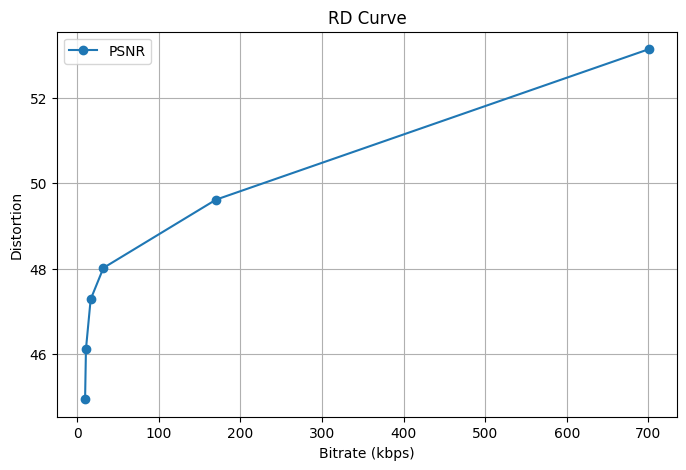

In [19]:
import matplotlib.pyplot as plt

df = pd.read_csv('/home/zhaoy/TaCo-Bench/lossy/video/statistics/vvenc_YCB-Slide.csv')
grouped = df.groupby('qp').agg({
    'bitrate': 'mean',
    'psnr': 'mean',
    'ssim': 'mean'
}).reset_index()

plt.figure(figsize=(8, 5))
plt.plot(grouped['bitrate'], grouped['psnr'], marker='o', label='PSNR')
# plt.plot(grouped['bitrate'], grouped['ssim'], marker='s', label='SSIM')
plt.xlabel('Bitrate (kbps)')
plt.ylabel('Distortion')
plt.title('RD Curve')
plt.legend()
plt.grid(True)
plt.show()